<a href="https://colab.research.google.com/github/Mansehaj-Singh/Drone-Orientation-Estimation/blob/main/ImuNET_Medium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving AP1.xlsx to AP1.xlsx
Saving AP2.xlsx to AP2.xlsx
Saving Qs_medium.xlsx to Qs_medium.xlsx
Saving SH1.xlsx to SH1.xlsx
Saving SH2.xlsx to SH2.xlsx
Saving XS1.xlsx to XS1.xlsx
Saving XS2.xlsx to XS2.xlsx


Total sequences: 20062
Static sequences: 12534
Dynamic sequences: 7528
Sequence distribution -> static: 12534, dynamic: 7528
Train sequences: (16049, 200, 6) (16049, 4)
Test sequences: (4013, 200, 6) (4013, 4)
IMUNet(
  (noise): CustomLayer()
  (input_block): Sequential(
    (0): Conv1d(6, 64, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (conv_1_1): DSConvRegular(
    (relu): ELU(alpha=1.0)
    (depth_wise): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), groups=64, bias=False)
    (bn_1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (point_wise): Conv1d(64, 64, kernel_size=(1,), stride=(1,), bias=False)
    (bn_2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv_1_2): DSConvRegular(
    (

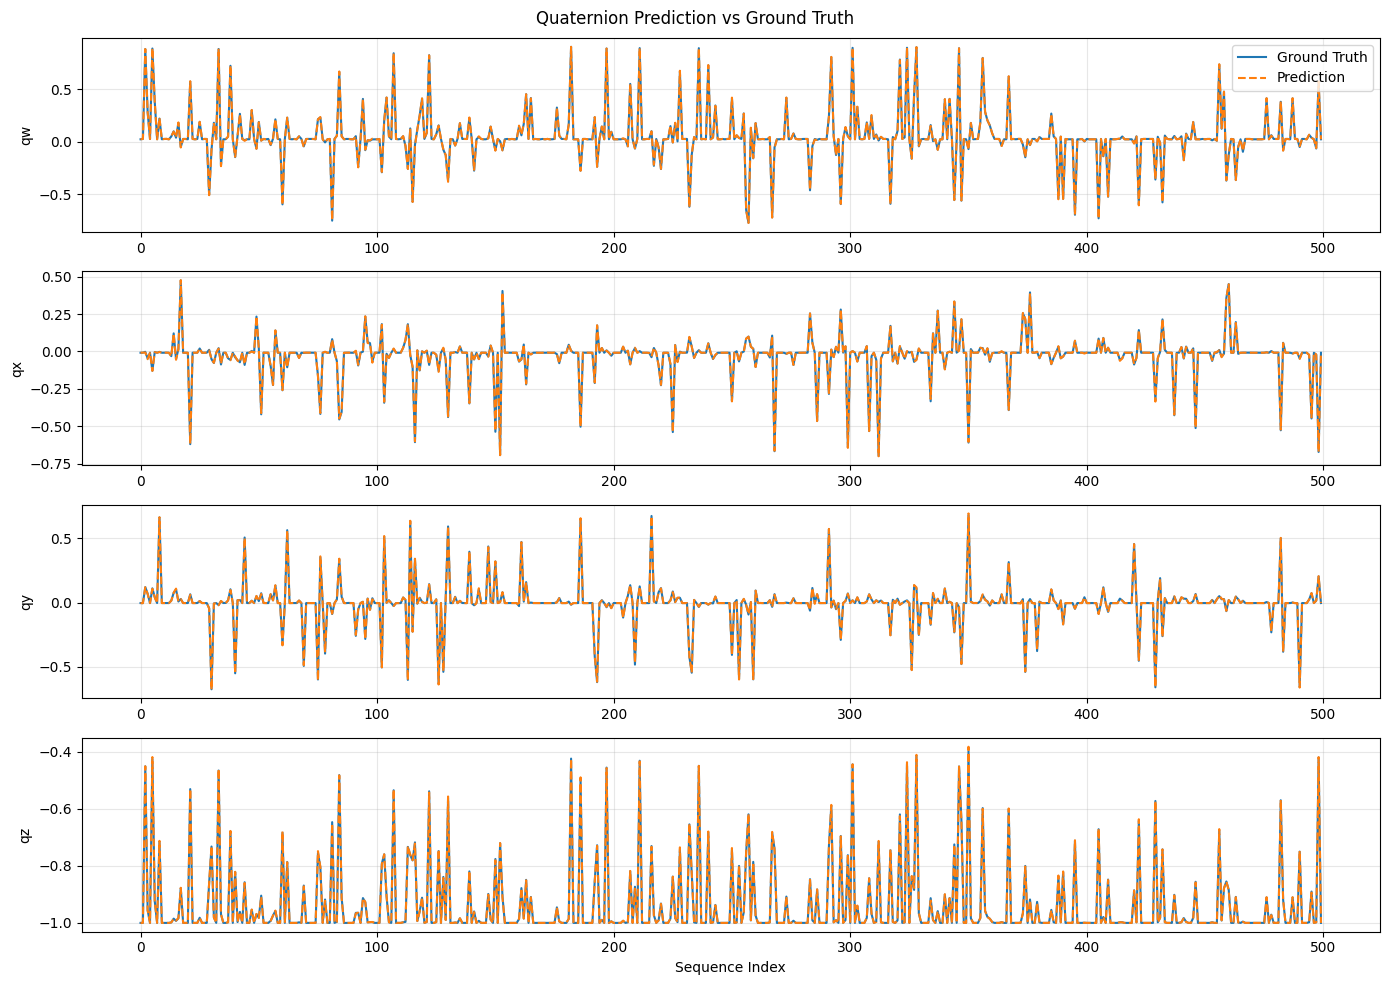

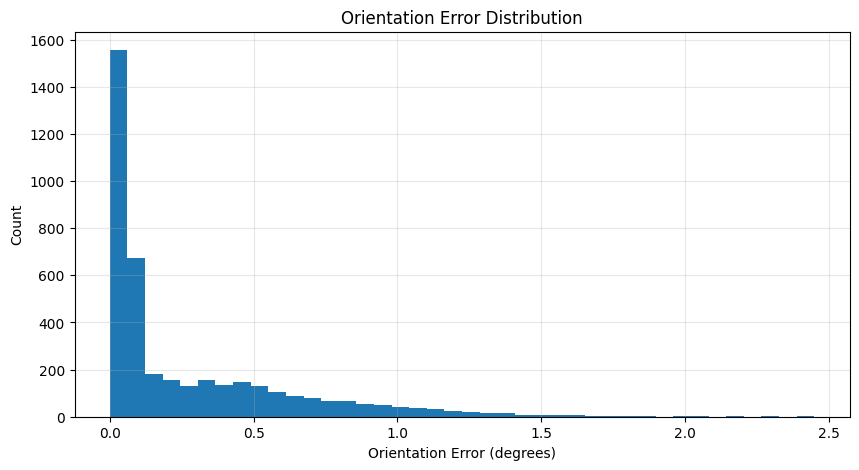

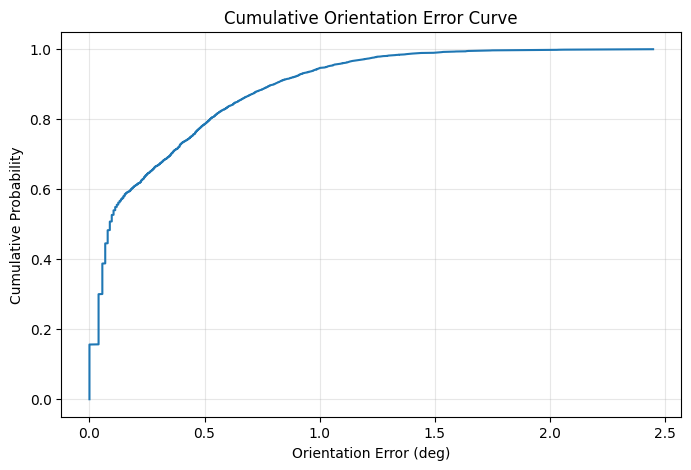

In [ ]:


import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =========================================================
# CONFIG
# =========================================================
SENSOR_FILES = ["XS1.xlsx", "XS2.xlsx", "AP1.xlsx", "AP2.xlsx", "SH1.xlsx", "SH2.xlsx"]
QUAT_FILE = "Qs_medium.xlsx"
SEQ_LEN = 200
MOTION_THRESHOLD = 0.1
BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-3
RANDOM_STATE = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# HELPERS
# =========================================================
def normalize_quaternions(q):
    q = q.astype(np.float32)
    n = np.linalg.norm(q, axis=1, keepdims=True)
    n = np.where(n == 0, 1.0, n)
    return q / n


def read_sensor_excel(path):
    df = pd.read_excel(path)
    if df.shape[1] < 14:
        raise ValueError(f"{path} has {df.shape[1]} columns, expected at least 14")
    df = df.iloc[:, :14].copy()
    df.columns = ["time", "ax", "ay", "az", "gx", "gy", "gz", "mx", "my", "mz", "ox", "oy", "oz", "ow"]
    return df


def create_sequences(X, y, motion, seq_len=200):
    X_seq, y_seq, m_seq = [], [], []
    n = len(X)
    if n < seq_len:
        return (
            np.empty((0, seq_len, X.shape[1]), dtype=np.float32),
            np.empty((0, y.shape[1]), dtype=np.float32),
            np.empty((0,), dtype=np.int64),
        )

    for i in range(n - seq_len + 1):
        j = i + seq_len
        X_seq.append(X[i:j])
        y_seq.append(y[j - 1])
        m_seq.append(1 if np.mean(motion[i:j]) > 0.5 else 0)

    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.float32), np.asarray(m_seq, dtype=np.int64)


def balanced_sequence_split(X, y, motion):
    X = np.asarray(X)
    y = np.asarray(y)
    motion = np.asarray(motion)

    static_mask = motion == 0
    dynamic_mask = motion == 1

    X_static, y_static = X[static_mask], y[static_mask]
    X_dynamic, y_dynamic = X[dynamic_mask], y[dynamic_mask]

    print(f"Sequence distribution -> static: {len(X_static)}, dynamic: {len(X_dynamic)}")

    def split_subset(Xs, ys):
        if len(Xs) < 2:
            return Xs, Xs[:0], ys, ys[:0]
        Xtr, Xte, ytr, yte = train_test_split(
            Xs, ys, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
        )
        return Xtr, Xte, ytr, yte

    Xs_tr, Xs_te, ys_tr, ys_te = split_subset(X_static, y_static)
    Xd_tr, Xd_te, yd_tr, yd_te = split_subset(X_dynamic, y_dynamic)

    if len(Xs_tr) and len(Xd_tr):
        X_train = np.concatenate([Xs_tr, Xd_tr], axis=0)
        y_train = np.concatenate([ys_tr, yd_tr], axis=0)
    else:
        X_train = Xs_tr if len(Xd_tr) == 0 else Xd_tr
        y_train = ys_tr if len(yd_tr) == 0 else yd_tr

    if len(Xs_te) and len(Xd_te):
        X_test = np.concatenate([Xs_te, Xd_te], axis=0)
        y_test = np.concatenate([ys_te, yd_te], axis=0)
    else:
        X_test = Xs_te if len(Xd_te) == 0 else Xd_te
        y_test = ys_te if len(yd_te) == 0 else yd_te

    tr_idx = np.random.permutation(len(X_train))
    te_idx = np.random.permutation(len(X_test))
    X_train, y_train = X_train[tr_idx], y_train[tr_idx]
    X_test, y_test = X_test[te_idx], y_test[te_idx]

    return X_train, X_test, y_train, y_test


def fit_transform_sequences(X_train, X_test):
    scaler = StandardScaler()
    n_tr, t_tr, c = X_train.shape
    n_te, t_te, _ = X_test.shape

    X_train_2d = X_train.reshape(-1, c)
    X_test_2d = X_test.reshape(-1, c)

    X_train_scaled = scaler.fit_transform(X_train_2d).reshape(n_tr, t_tr, c)
    X_test_scaled = scaler.transform(X_test_2d).reshape(n_te, t_te, c)
    return X_train_scaled, X_test_scaled, scaler


def quaternion_geodesic_loss(pred, target):
    pred = F.normalize(pred, p=2, dim=1)
    target = F.normalize(target, p=2, dim=1)
    dot = torch.abs(torch.sum(pred * target, dim=1))
    dot = torch.clamp(dot, -1.0 + 1e-7, 1.0 - 1e-7)
    angle = 2.0 * torch.acos(dot)
    return angle.mean()


def quaternion_rmse(pred, target):
    return np.sqrt(np.mean((pred - target) ** 2, axis=0))


def quaternion_angle_error_deg(pred, target):
    pred = pred / np.linalg.norm(pred, axis=1, keepdims=True).clip(min=1e-8)
    target = target / np.linalg.norm(target, axis=1, keepdims=True).clip(min=1e-8)
    dots = np.abs(np.sum(pred * target, axis=1))
    dots = np.clip(dots, -1.0, 1.0)
    angles = 2.0 * np.degrees(np.arccos(dots))
    return angles

# =========================================================
# DATA PREPARATION
# =========================================================
if QUAT_FILE not in os.listdir():
    raise FileNotFoundError(f"{QUAT_FILE} not found. Please upload it.")

quat_df = pd.read_excel(QUAT_FILE)
if quat_df.shape[1] < 4:
    raise ValueError("Quaternion file must have at least 4 columns")
quat_df = quat_df.iloc[:, :4].copy()
quat_df.columns = ["qw", "qx", "qy", "qz"]
quat_all = normalize_quaternions(quat_df.to_numpy(np.float32))

quat_offset = 0
X_seq_all, y_seq_all, motion_seq_all = [], [], []

for fname in SENSOR_FILES:
    if fname not in os.listdir():
        raise FileNotFoundError(f"{fname} not found. Please upload it.")

    df = read_sensor_excel(fname)
    n_available = len(quat_all) - quat_offset
    if n_available <= 0:
        break

    n = min(len(df), n_available)
    df = df.iloc[:n].reset_index(drop=True)
    quat_slice = quat_all[quat_offset:quat_offset + n]
    quat_offset += n

    motion = (np.sqrt(df["gx"].to_numpy() ** 2 + df["gy"].to_numpy() ** 2 + df["gz"].to_numpy() ** 2) > MOTION_THRESHOLD).astype(np.int64)
    X_raw = df[["ax", "ay", "az", "gx", "gy", "gz"]].to_numpy(np.float32)
    y_raw = quat_slice.astype(np.float32)

    Xs, ys, ms = create_sequences(X_raw, y_raw, motion, seq_len=SEQ_LEN)
    if len(Xs) > 0:
        X_seq_all.append(Xs)
        y_seq_all.append(ys)
        motion_seq_all.append(ms)

if len(X_seq_all) == 0:
    raise RuntimeError("No sequences were created. Check file lengths and SEQ_LEN.")

X_seq = np.concatenate(X_seq_all, axis=0)
y_seq = np.concatenate(y_seq_all, axis=0)
m_seq = np.concatenate(motion_seq_all, axis=0)

print("Total sequences:", len(X_seq))
print("Static sequences:", int(np.sum(m_seq == 0)))
print("Dynamic sequences:", int(np.sum(m_seq == 1)))

X_train, X_test, y_train, y_test = balanced_sequence_split(X_seq, y_seq, m_seq)
X_train, X_test, scaler = fit_transform_sequences(X_train, X_test)

print("Train sequences:", X_train.shape, y_train.shape)
print("Test sequences:", X_test.shape, y_test.shape)

# =========================================================
# DATASET
# =========================================================
class IMUSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx].T, dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.float32)
        return x, y


train_loader = DataLoader(IMUSequenceDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
test_loader = DataLoader(IMUSequenceDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)


class CustomLayer(nn.Module):
    def __init__(self, feat_dim=1200):
        super().__init__()
        self.W = nn.Parameter(torch.randn(1, feat_dim) * 0.01)
        self.b = nn.Parameter(torch.zeros(1, feat_dim))

    def forward(self, tensor_a, tensor_b):
        return tensor_a - self.W * tensor_b + self.b


class DSConv(nn.Module):
    def __init__(self, f_3x3, f_1x1, kernel_size, stride=1, dilation=1, downsample=False, padding=1, inplace=True):
        super().__init__()
        self.relu = nn.ELU()
        self.depth_wise = nn.Conv1d(
            f_3x3, f_3x3, kernel_size=kernel_size, groups=f_3x3,
            stride=stride, padding=padding, bias=False
        )
        self.bn_1 = nn.BatchNorm1d(f_3x3)
        self.point_wise = nn.Conv1d(f_3x3, f_1x1, kernel_size=1, bias=False)
        self.bn_2 = nn.BatchNorm1d(f_1x1)
        self.downsample = downsample
        self.downsample_ = nn.Sequential(
            nn.Conv1d(f_3x3, f_1x1, kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm1d(f_1x1)
        )

    def forward(self, x):
        residual = x
        out = self.depth_wise(x)
        out = self.bn_1(out)
        out = self.relu(out)
        out = self.point_wise(out)
        out = self.bn_2(out)
        out = self.relu(out)
        if self.downsample:
            residual = self.downsample_(x)
        out = out + residual.clone()
        out = self.relu(out)
        return out


class DSConvRegular(nn.Module):
    def __init__(self, f_3x3, f_1x1, kernel_size, stride=1, dilation=1, downsample=False, padding=1, inplace=True):
        super().__init__()
        self.relu = nn.ELU()
        self.depth_wise = nn.Conv1d(
            f_3x3, f_3x3, kernel_size=kernel_size, groups=f_3x3,
            stride=stride, padding=padding, bias=False
        )
        self.bn_1 = nn.BatchNorm1d(f_3x3)
        self.point_wise = nn.Conv1d(f_3x3, f_1x1, kernel_size=1, bias=False)
        self.bn_2 = nn.BatchNorm1d(f_1x1)

    def forward(self, x):
        residual = x
        out = self.depth_wise(x)
        out = self.bn_1(out)
        out = self.relu(out)
        out = self.point_wise(out)
        out = self.bn_2(out)
        out = self.relu(out)
        out = out + residual.clone()
        out = self.relu(out)
        return out


class IMUNet(nn.Module):
    def __init__(self, num_classes=4, input_size=(1, 6, 200), sampling_rate=200, num_T=32, num_S=64, hidden=64, dropout_rate=0.5):
        super().__init__()
        self.noise = CustomLayer(feat_dim=1200)
        self.input_mult = 64

        self.input_block = nn.Sequential(
            nn.Conv1d(6, self.input_mult, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(self.input_mult),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1)
        )

        self.conv_1_1 = DSConvRegular(self.input_mult, 64, 3, downsample=False, padding=1, stride=1)
        self.conv_1_2 = DSConvRegular(64, 64, 3, downsample=False, padding=1, stride=1)

        self.conv_3_1 = DSConv(64, 64, 3, downsample=True, padding=1, stride=1)
        self.conv_3_2 = DSConvRegular(64, 64, 3, downsample=False, padding=1, stride=1)

        self.conv_4_1 = DSConv(64, 128, 3, downsample=True, padding=1, stride=2)
        self.conv_4_2 = DSConvRegular(128, 128, 3, downsample=False, padding=1, stride=1)

        self.conv_5_1 = DSConv(128, 256, 3, downsample=True, padding=1, stride=2)
        self.conv_5_2 = DSConvRegular(256, 256, 3, downsample=False, padding=1, stride=1)

        self.conv_6_1 = DSConv(256, 512, 3, downsample=True, padding=1, stride=2)
        self.conv_6_2 = DSConvRegular(512, 512, 3, downsample=False, padding=1, stride=1)

        self.conv_7_1 = DSConv(512, 1024, 3, downsample=True, padding=1, stride=2)
        self.conv_7_2 = DSConvRegular(1024, 1024, 3, downsample=False, padding=1, stride=1)

        self.relu = nn.ELU()
        self.output_block = nn.Sequential(
            nn.Conv1d(in_channels=1024, out_channels=400, kernel_size=2, stride=1),
            nn.BatchNorm1d(400),
        )
        self.fc = nn.Sequential(
            nn.Linear(1200, num_classes)
        )

    def forward(self, x):
        input_val = x.view(x.size(0), -1)
        x = self.input_block(x)

        y = self.conv_1_1(x)
        y = self.conv_1_2(y)

        x = y
        y = self.conv_3_1(x)
        y = self.conv_3_2(y)

        y = self.conv_4_1(y)
        y = self.conv_4_2(y)

        y = self.conv_5_1(y)
        y = self.conv_5_2(y)

        y = self.conv_6_1(y)
        y = self.conv_6_2(y)

        y = self.conv_7_1(y)
        y = self.conv_7_2(y)

        out = self.output_block(y)
        out = out.view(out.size(0), -1)
        out = self.noise(out, input_val)
        out = self.relu(out)
        out = self.fc(out)
        out = F.normalize(out, p=2, dim=1)
        return out

    def get_num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


model = IMUNet(num_classes=4).to(DEVICE)
print(model)
print("Trainable params:", model.get_num_params())

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


criterion = quaternion_geodesic_loss

# =========================================================
# TRAINING
# =========================================================
best_loss = float("inf")
best_state = None

for epoch in range(20):
    model.train()
    running = 0.0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        running += loss.item()

    scheduler.step()
    train_loss = running / max(len(train_loader), 1)

    model.eval()
    val_running = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            pred = model(xb)
            loss = criterion(pred, yb)
            val_running += loss.item()

    val_loss = val_running / max(len(test_loader), 1)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | train_loss={train_loss:.6f} | test_loss={val_loss:.6f}")

    if val_loss < best_loss:
        best_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)

torch.save(model.state_dict(), "imunet_quaternion_colab.pth")
print("Saved model to imunet_quaternion_colab.pth")

# =========================================================
# EVALUATION
# =========================================================
model.eval()

preds = []
gts = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)

        out = model(xb).cpu().numpy()

        preds.append(out)
        gts.append(yb.numpy())

preds = np.concatenate(preds, axis=0)
gts = np.concatenate(gts, axis=0)

# =========================================================
# NORMALIZE QUATERNIONS
# =========================================================
preds = preds / np.linalg.norm(preds, axis=1, keepdims=True)
gts = gts / np.linalg.norm(gts, axis=1, keepdims=True)

# =========================================================
# RMSE
# =========================================================
rmse_per_component = np.sqrt(np.mean((preds - gts) ** 2, axis=0))

mean_rmse = np.mean(rmse_per_component)

# =========================================================
# ORIENTATION ERROR (DEGREES)
# =========================================================
dots = np.abs(np.sum(preds * gts, axis=1))
dots = np.clip(dots, -1.0, 1.0)

angle_errors_rad = 2 * np.arccos(dots)
angle_errors_deg = np.degrees(angle_errors_rad)

mean_orientation_error = np.mean(angle_errors_deg)
median_orientation_error = np.median(angle_errors_deg)

# =========================================================
# mAP@0.5 and mAP@0.5:0.95
# Quaternion-style adaptation
# =========================================================

# mAP@0.5
map_05 = np.mean(angle_errors_rad <= 0.5)

# mAP@0.5:0.95
thresholds = np.arange(0.5, 1.0, 0.05)

aps = []

for t in thresholds:
    aps.append(np.mean(angle_errors_rad <= t))

map_5095 = np.mean(aps)

# =========================================================
# PRINT METRICS
# =========================================================
print("\n================ FINAL METRICS ================\n")

print("RMSE per quaternion component:")
print(f"qw: {rmse_per_component[0]:.6f}")
print(f"qx: {rmse_per_component[1]:.6f}")
print(f"qy: {rmse_per_component[2]:.6f}")
print(f"qz: {rmse_per_component[3]:.6f}")

print(f"\nMean Component RMSE: {mean_rmse:.6f}")

print(f"\nMean Orientation Error (deg): {mean_orientation_error:.6f}")
print(f"Median Orientation Error (deg): {median_orientation_error:.6f}")

print(f"\nmAP@0.5 : {map_05:.6f}")
print(f"mAP@0.5:0.95 : {map_5095:.6f}")

# =========================================================
# SHOW SAMPLE PREDICTIONS
# =========================================================
print("\n================ SAMPLE PREDICTIONS ================\n")

for i in range(5):

    print(f"\nSample {i+1}")

    print("Ground Truth:")
    print(gts[i])

    print("Predicted:")
    print(preds[i])

    print(f"Orientation Error (deg): {angle_errors_deg[i]:.4f}")

# =========================================================
# PLOTS
# =========================================================

labels = ["qw", "qx", "qy", "qz"]

show_n = min(500, len(preds))

plt.figure(figsize=(14,10))

for i in range(4):

    plt.subplot(4,1,i+1)

    plt.plot(gts[:show_n, i],
             label="Ground Truth",
             linewidth=1.5)

    plt.plot(preds[:show_n, i],
             linestyle='--',
             label="Prediction")

    plt.ylabel(labels[i])

    plt.grid(alpha=0.3)

    if i == 0:
        plt.legend()

plt.xlabel("Sequence Index")
plt.suptitle("Quaternion Prediction vs Ground Truth")
plt.tight_layout()
plt.show()

# =========================================================
# ORIENTATION ERROR HISTOGRAM
# =========================================================
plt.figure(figsize=(10,5))

plt.hist(angle_errors_deg, bins=40)

plt.xlabel("Orientation Error (degrees)")
plt.ylabel("Count")

plt.title("Orientation Error Distribution")

plt.grid(alpha=0.3)

plt.show()

# =========================================================
# CUMULATIVE ERROR CURVE
# =========================================================
sorted_errors = np.sort(angle_errors_deg)

cumulative = np.arange(len(sorted_errors)) / len(sorted_errors)

plt.figure(figsize=(8,5))

plt.plot(sorted_errors, cumulative)

plt.xlabel("Orientation Error (deg)")
plt.ylabel("Cumulative Probability")

plt.title("Cumulative Orientation Error Curve")

plt.grid(alpha=0.3)

plt.show()